<a href="https://colab.research.google.com/github/devanshRaana/PS-/blob/main/PS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile


In [47]:
ZIP_PATH = "/content/mnist-dataset.zip"
EXTRACT_PATH = "/content/mnist"

import os
import zipfile

if not os.path.exists(ZIP_PATH):
    print(f"Error: The file '{ZIP_PATH}' was not found.")
    print("Please ensure the 'mnist-dataset.zip' file is uploaded to '/content/' or update ZIP_PATH to the correct location.")
else:
    try:
        with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)

        print("Dataset extracted")

        if os.path.exists(EXTRACT_PATH):
            for files in os.listdir(EXTRACT_PATH):
                print(files)
        else:
            print(f"Extraction path '{EXTRACT_PATH}' not found after extraction attempt.")
    except zipfile.BadZipFile:
        print(f"Error: The file '{ZIP_PATH}' is not a valid zip file.")
        print("Please ensure you have uploaded the correct 'mnist-dataset.zip' file and it is not corrupted.")

Dataset extracted
train-images.idx3-ubyte
train-images-idx3-ubyte
t10k-images-idx3-ubyte
train-labels-idx1-ubyte
t10k-labels-idx1-ubyte
t10k-labels.idx1-ubyte
t10k-images.idx3-ubyte
train-labels.idx1-ubyte


In [ ]:
from IPython.core.interactiveshell import magic
def load_images(path):
  with open(path, "rb") as f:
    magic = int.from_bytes(f.read(4), "big")
    num_images = int.from_bytes(f.read(4), "big")
    rows = int.from_bytes(f.read(4), "big")
    cols = int.from_bytes(f.read(4), "big")

    images = np.frombuffer(
        f.read(),
        dtype = np.uint8
    )
    images = images.reshape(num_images, rows, cols)
    return images

def load_labels(path):
  with open(path, "rb") as f:
    magic = int.from_bytes(f.read(4), "big")
    num_labels = int.from_bytes(f.read(4), "big")

    labels = np.frombuffer(
        f.read(),
        dtype = np.uint8
    )
    return labels

In [ ]:
X_train = load_images("/content/mnist/train-images.idx3-ubyte")
y_train = load_labels("/content/mnist/train-labels.idx1-ubyte")
X_test = load_images( "/content/mnist/t10k-images.idx3-ubyte")
y_test = load_labels("/content/mnist/t10k-labels.idx1-ubyte")

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Test Images :", X_test.shape)
print("Test Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Test Images : (10000, 28, 28)
Test Labels : (10000,)


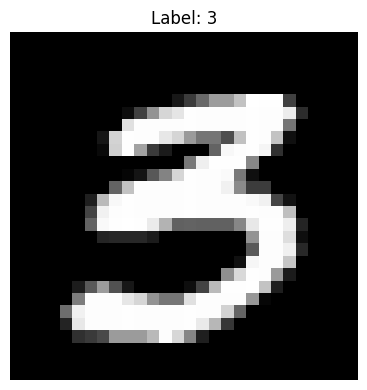

In [ ]:
import random as rn
plt.figure(figsize=(4,4))
indx = rn.randint(0, 10000)

plt.imshow(X_train[indx], cmap="gray")
plt.title(f"Label: {y_train[indx]}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("\n")
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())
print("\n")
print("Data Type :", X_train.dtype)
print("\n")
print("Uniques labels: ")
print(np.unique(y_train))

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)


Minimum Pixel Value : 0
Maximum Pixel Value : 255


Data Type : uint8


Uniques labels: 
[0 1 2 3 4 5 6 7 8 9]


In [ ]:
unique ,counts = np.unique(y_train, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count}")
print("\n")
print(X_train[indx], y_train[indx])

Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  23  59 104 156 156
  194 255 254 254  64   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  13  65 147 214 229 254 253 253 253
  253 254 253 253 236  45   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 2

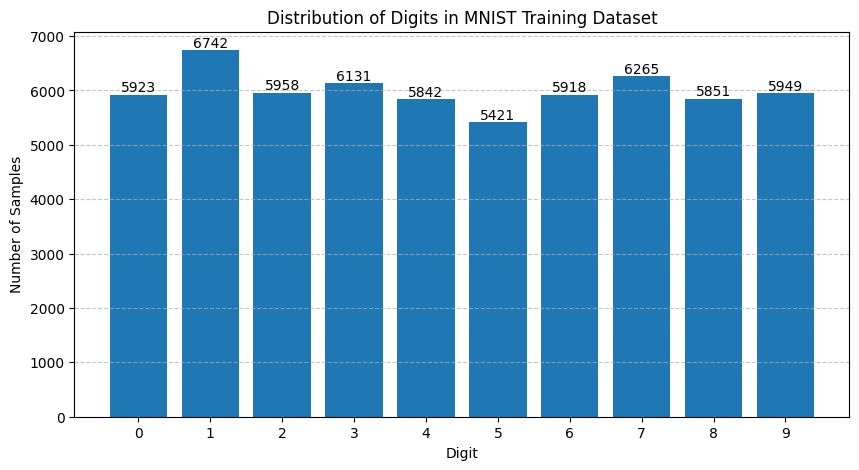

In [ ]:

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))
bars = plt.bar(unique, counts)

plt.title("Distribution of Digits in MNIST Training Dataset")
plt.xlabel("Digit")
plt.ylabel("Number of Samples")

plt.xticks(unique)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
X_train_flat = X_train.reshape(60000, 28*28)
X_test_flat = X_test.reshape(10000, 28*28)

print("Target Shape\n")
print("Flattened Training Images Shape :", X_train_flat.shape)
print("Flattened Test Images Shape :", X_test_flat.shape)

print("Flattened Training Labels Shape :", y_train.shape)
print("Flattened Test Labels Shape :", y_test.shape)
print("\n")

print("Current Shape\n")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
print("Training Shape :", X_train_flat.shape)
print("Test Shape :", X_test_flat.shape)


#Normalization
X_train_flat = X_train_flat.astype(np.float32) / 255.0
X_test_flat = X_test_flat.astype(np.float32) / 255.0
print("Minimum :", X_train_flat.min())
print("Maximum :", X_train_flat.max())

Target Shape

Flattened Training Images Shape : (60000, 784)
Flattened Test Images Shape : (10000, 784)
Flattened Training Labels Shape : (60000,)
Flattened Test Labels Shape : (10000,)


Current Shape

Training Shape : (60000, 784)
Test Shape : (10000, 784)
Minimum : 0.0
Maximum : 1.0


In [ ]:


def one_hot_encode(labels, num_classes=10):

  encoded = np.zeros(
      (labels.size, num_classes)
  )
  encoded[
        np.arange(labels.size),
        labels
  ] = 1

  return encoded

In [ ]:
y_train_encoded = one_hot_encode(y_train)
y_test_encoded = one_hot_encode(y_test)

print(f"Original Label: {y_train[indx]}")

print(f"Encoded Label: {y_train_encoded[indx]}")

print(f"Shape: {y_train_encoded.shape}")


Original Label: 3
Encoded Label: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Shape: (60000, 10)


In [48]:
np.random.seed(42)

indices = np.random.permutation(
    X_train_flat.shape[0]
)

X_train_flat = X_train_flat[indices]
y_train_encoded = y_train_encoded[indices]
validation_size = 6000

X_val = X_train_flat[:validation_size]
y_val = y_train_encoded[:validation_size]

X_train_final = X_train_flat[validation_size:]
y_train_final = y_train_encoded[validation_size:]
print("Training Set:")
print(X_train_final.shape)
print(y_train_final.shape)

print("\nValidation Set:")
print(X_val.shape)
print(y_val.shape)

print("\nTest Set:")
print(X_test_flat.shape)
print(y_test_encoded.shape)

Training Set:
(54000, 784)
(54000, 10)

Validation Set:
(6000, 784)
(6000, 10)

Test Set:
(10000, 784)
(10000, 10)


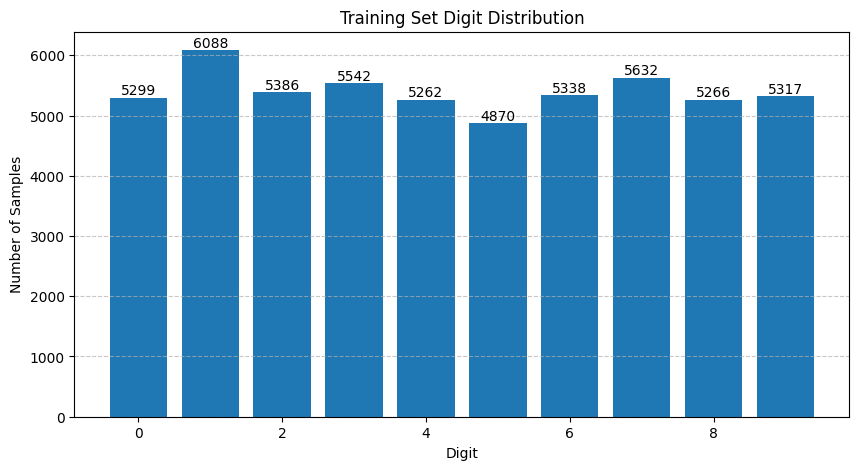

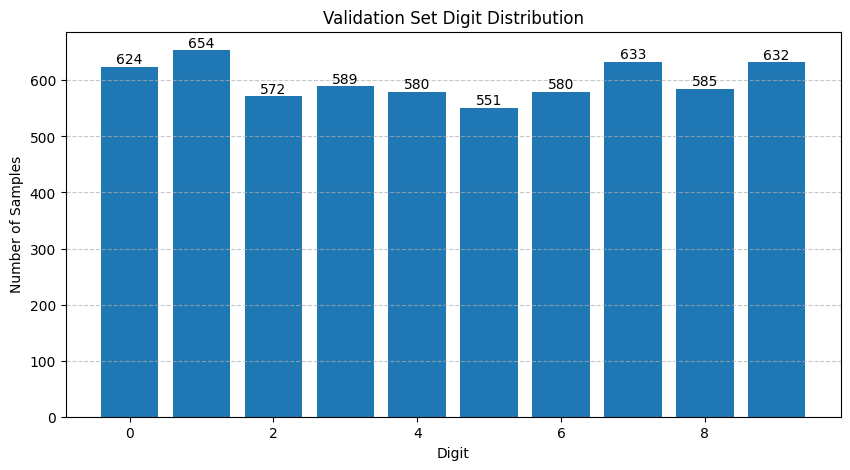

In [ ]:
#testing block
train_labels = np.argmax(y_train_final, axis=1)

unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10,5))
plt.bar(unique, counts)

plt.title("Training Set Digit Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Samples")

for i, count in zip(unique, counts):
    plt.text(i, count, str(count),
             ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
val_labels = np.argmax(y_val, axis=1)

unique, counts = np.unique(val_labels, return_counts=True)

plt.figure(figsize=(10,5))
plt.bar(unique, counts)

plt.title("Validation Set Digit Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Samples")

for i, count in zip(unique, counts):
    plt.text(i, count, str(count),
             ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
INPUT_SIZE = 784
HIDDEN1_SIZE = 128
HIDDEN2_SIZE = 64
OUTPUT_SIZE = 10

print("Input Layer :", INPUT_SIZE)
print("Hidden Layer 1:", HIDDEN1_SIZE)
print("Hidden Layer 2:", HIDDEN2_SIZE)
print("Output Layer :", OUTPUT_SIZE)

def initialize_parameters():

    np.random.seed(42)

    W1 = np.random.randn(784,128) * np.sqrt(2/784)
    b1 = np.zeros((1,128))

    W2 = np.random.randn(128,64) * np.sqrt(2/128)
    b2 = np.zeros((1,64))

    W3 = np.random.randn(64,10) * np.sqrt(2/64)
    b3 = np.zeros((1,10))

    return W1,b1,W2,b2,W3,b3



Input Layer : 784
Hidden Layer 1: 128
Hidden Layer 2: 64
Output Layer : 10


In [ ]:
W1,b1,W2,b2,W3,b3 = initialize_parameters()

print("W1 :", W1.shape)
print("b1 :", b1.shape)

print("W2 :", W2.shape)
print("b2 :", b2.shape)

print("W3 :",W3.shape)
print("b3 :",b3.shape)

W1 : (784, 128)
b1 : (1, 128)
W2 : (128, 64)
b2 : (1, 64)
W3 : (64, 10)
b3 : (1, 10)


In [45]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def softmax(Z):

    Z_shifted = Z - np.max(
        Z,
        axis=1,
        keepdims=True
    )

    exp_Z = np.exp(Z_shifted)

    return exp_Z / np.sum(
        exp_Z,
        axis=1,
        keepdims=True
    )
test = np.array([[2.1, 1.4, 5.9]])
print(softmax(test))
print(np.sum(softmax(test)))

[[0.02164607 0.01074912 0.96760481]]
1.0


In [ ]:
def forward_propagation(X,W1,b1,W2,b2,W3,b3):

    Z1 = np.dot(X,W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1,W2) + b2
    A2 = relu(Z2)

    Z3 = np.dot(A2,W3) + b3
    A3 = softmax(Z3)

    cache = {
        "Z1":Z1,
        "A1":A1,
        "Z2":Z2,
        "A2":A2,
        "Z3":Z3,
        "A3":A3
    }

    return A3,cache

In [ ]:
X_sample = X_train_final[:5]

predictions,cache = forward_propagation(
    X_sample,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

# train_labels = np.argmax(y_train_final,axis=1)
# print(train_labels[:5])

print(predictions.shape)
print(predictions[0])
print(np.sum(predictions[0]))
print(np.max(predictions[0]))
predicted_digit = np.argmax(predictions[0])
print(predicted_digit)

(5, 10)
[0.06902082 0.09690726 0.10093865 0.11921127 0.12285651 0.11908683
 0.09956115 0.10204891 0.07816148 0.09220713]
1.0000000000000002
0.12285650893789454
4


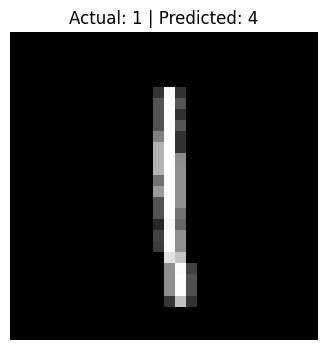

Actual: 1
Predicted: 4
Probabilities:
[0.06902082 0.09690726 0.10093865 0.11921127 0.12285651 0.11908683
 0.09956115 0.10204891 0.07816148 0.09220713]


In [ ]:
#test debugging
train_labels = np.argmax(y_train_final, axis=1)

plt.figure(figsize=(4,4))
plt.imshow(X_sample[0].reshape(28,28), cmap='gray')

plt.title(
    f"Actual: {train_labels[0]} | Predicted: {np.argmax(predictions[0])}"
)

plt.axis("off")
plt.show()

print("Actual:", train_labels[0])
print("Predicted:", np.argmax(predictions[0]))
print("Probabilities:")
print(predictions[0])

In [ ]:
#Cross Entropy loss
def compute_loss(y_true, y_pred):

    epsilon = 1e-15

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.sum(
        y_true * np.log(y_pred)
    ) / y_true.shape[0]

    return loss

In [ ]:
#check for loss functiong
good_prediction = np.array([
    [0.01,0.01,0.90,0.01,0.01,
     0.01,0.01,0.01,0.01,0.02]
])

true_label = np.array([
    [0,0,1,0,0,0,0,0,0,0]
])

print(
    compute_loss(
        true_label,
        good_prediction
    )
)
bad_prediction = np.array([
    [0.70,0.10,0.02,0.05,0.02,
     0.03,0.02,0.02,0.02,0.02]
])

print(
    compute_loss(
        true_label,
        bad_prediction
    )
)

0.10536051565782628
3.912023005428146


In [ ]:
loss = compute_loss(
    y_train_final[:5],
    predictions
)

print(loss)

2.399588908081047


In [ ]:
def backward_propagation(
    X,
    Y,
    W2,
    W3,
    cache
):

    m = X.shape[0]

    A1 = cache["A1"]
    A2 = cache["A2"]
    A3 = cache["A3"]

    Z1 = cache["Z1"]
    Z2 = cache["Z2"]

    # Output Layer

    dZ3 = A3 - Y

    dW3 = (A2.T @ dZ3) / m

    db3 = np.sum(
        dZ3,
        axis=0,
        keepdims=True
    ) / m

    # Hidden Layer 2

    dA2 = dZ3 @ W3.T

    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = (A1.T @ dZ2) / m

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    ) / m

    # Hidden Layer 1

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (X.T @ dZ1) / m

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    ) / m

    gradients = {
        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2,

        "dW3": dW3,
        "db3": db3
    }

    return gradients


In [ ]:
def update_parameters(
    W1,b1,
    W2,b2,
    W3,b3,
    gradients,
    learning_rate
):

    W1 -= learning_rate * gradients["dW1"]
    b1 -= learning_rate * gradients["db1"]

    W2 -= learning_rate * gradients["dW2"]
    b2 -= learning_rate * gradients["db2"]

    W3 -= learning_rate * gradients["dW3"]
    b3 -= learning_rate * gradients["db3"]

    return W1,b1,W2,b2,W3,b3

In [ ]:
def train(
    X,
    Y,
    W1,b1,
    W2,b2,
    W3,b3,
    epochs,
    learning_rate,
    batch_size
):

    loss_history = []

    m = X.shape[0]

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]
        Y_shuffled = Y[indices]

        epoch_loss = 0

        for start in range(0, m, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            Y_batch = Y_shuffled[start:end]

            predictions, cache = forward_propagation(
                X_batch,
                W1,b1,
                W2,b2,
                W3,b3
            )

            loss = compute_loss(
                Y_batch,
                predictions
            )

            gradients = backward_propagation(
                X_batch,
                Y_batch,
                W2,
                W3,
                cache
            )

            W1,b1,W2,b2,W3,b3 = update_parameters(
                W1,b1,
                W2,b2,
                W3,b3,
                gradients,
                learning_rate
            )

            epoch_loss += loss

        epoch_loss /= (m // batch_size)

        loss_history.append(epoch_loss)

        if epoch % 10 == 0:

            print(
                f"Epoch {epoch} | Loss = {epoch_loss:.4f}"
            )

    return (
        W1,b1,
        W2,b2,
        W3,b3,
        loss_history
    )

In [ ]:
W1,b1,W2,b2,W3,b3,loss_history = train(
    X_train_final,
    y_train_final,
    W1,b1,
    W2,b2,
    W3,b3,
    epochs=100,
    learning_rate=0.01,
    batch_size=128
)

Epoch 0 | Loss = 1.1759
Epoch 10 | Loss = 0.2323
Epoch 20 | Loss = 0.1656
Epoch 30 | Loss = 0.1285
Epoch 40 | Loss = 0.1042
Epoch 50 | Loss = 0.0868
Epoch 60 | Loss = 0.0735
Epoch 70 | Loss = 0.0630
Epoch 80 | Loss = 0.0544
Epoch 90 | Loss = 0.0474


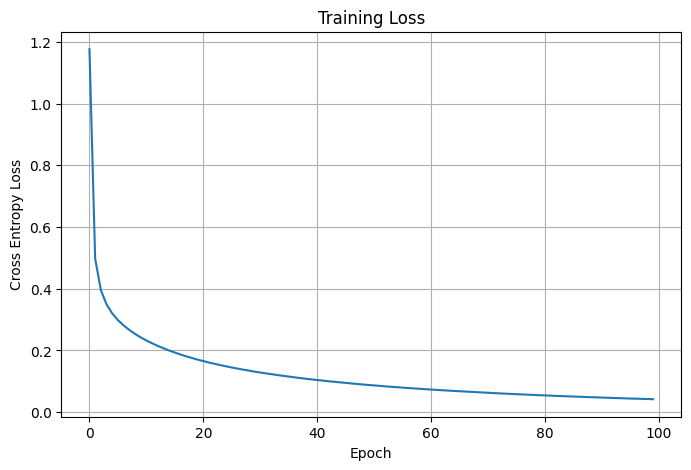

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

In [ ]:
train_predictions, _ = forward_propagation(
    X_train_final,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

train_accuracy = np.mean(
    np.argmax(train_predictions, axis=1)==np.argmax(y_train_final, axis=1)
)

print(f"Training Accuracy: {train_accuracy*100:.2f}%")

Training Accuracy: 99.00%


In [ ]:
val_predictions, _ = forward_propagation(
    X_val,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

val_accuracy = np.mean(
    np.argmax(val_predictions, axis=1)
    ==
    np.argmax(y_val, axis=1)
)

print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Validation Accuracy: 97.50%


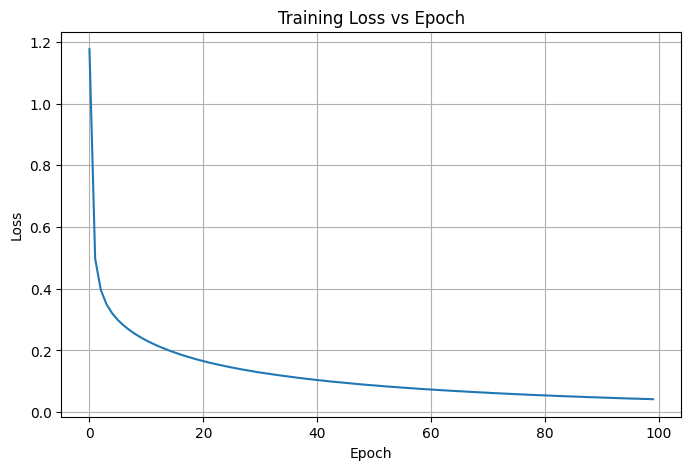

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
test_predictions, _ = forward_propagation(
    X_test_flat,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

test_accuracy = np.mean(
    np.argmax(test_predictions, axis=1)
    ==
    np.argmax(y_test_encoded, axis=1)
)

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 97.52%


In [ ]:
predicted_labels = np.argmax(
    test_predictions,
    axis=1
)

true_labels = np.argmax(
    y_test_encoded,
    axis=1
)

conf_matrix = np.zeros((10,10), dtype=int)

for t, p in zip(true_labels, predicted_labels):
    conf_matrix[t,p] += 1

print(conf_matrix)

[[ 966    0    1    1    1    3    1    3    4    0]
 [   0 1122    4    0    0    0    3    2    4    0]
 [   3    1 1013    2    1    1    1    5    5    0]
 [   0    0    6  990    0    6    0    1    3    4]
 [   1    0    5    0  961    0    2    2    1   10]
 [   3    1    1   13    3  857    5    1    6    2]
 [   4    3    2    1    4    9  933    1    1    0]
 [   0    8    8    3    2    0    0  996    3    8]
 [   3    0    5    7    3    5    3    3  943    2]
 [   4    6    0    6    7    5    1    5    4  971]]
